Part of EDA is understanding the relationship between two (or more variables).

In this notebook, we'll continue exploring the Palmer Penguins dataset and learn tools for looking at relationships between variables.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
penguins = pd.read_csv('./data/penguins.csv')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


Like in the single-variable case, the tool we use depends on the type of the variables we are examining.

## Examining Two Categorical Variables

What if we want to look at a cross-tabulation of the number of observations of each sex broken down by species. 

For this, we can use the `pandas` `crosstab` function. What we need to do is to pass in the two columns we want to create the table based on.

In [5]:
pd.crosstab(penguins['island'], penguins['species'])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


We can take the results and create a plot.

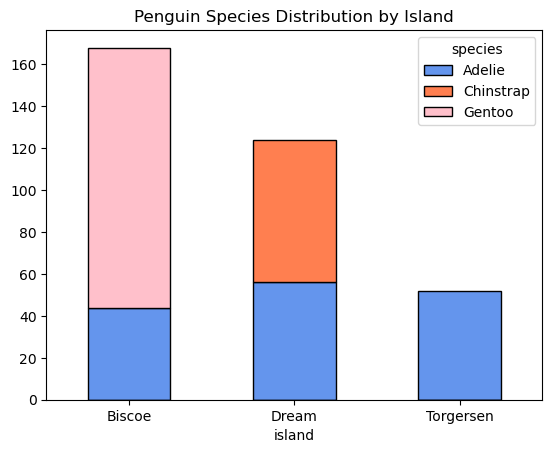

In [6]:
pd.crosstab(penguins['island'], penguins['species']).plot(kind = 'bar', 
                                                          stacked = True,       # stacked as opposed to side-by-side
                                                          color = ['cornflowerblue', 'coral', 'pink'],     # change the default colors
                                                          edgecolor = 'black')              # add a border to the bars
plt.title('Penguin Species Distribution by Island')                   # add a title
plt.xticks(rotation = 0);                                             # change the appearance of the x tick labels

You can also normalize the cross-tabulation. Since we are working with two variables here, we can normalize in a number of ways. 

For example, if we just want the proportion of total observations that are contained in each cell, we can use the `normalize = 'all'` option.

In [7]:
pd.crosstab(penguins['island'], penguins['species'],  normalize = 'all')

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,0.127907,0.000000,0.360465
Dream,0.162791,0.197674,0.000000
Torgersen,0.151163,0.000000,0.000000


Or if we want proportions by row, we can use the `normalize = 'index'` option.

In [8]:
pd.crosstab(penguins['island'], penguins['species'],  normalize = 'index')

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,0.261905,0.000000,0.738095
Dream,0.451613,0.548387,0.000000
Torgersen,1.000000,0.000000,0.000000


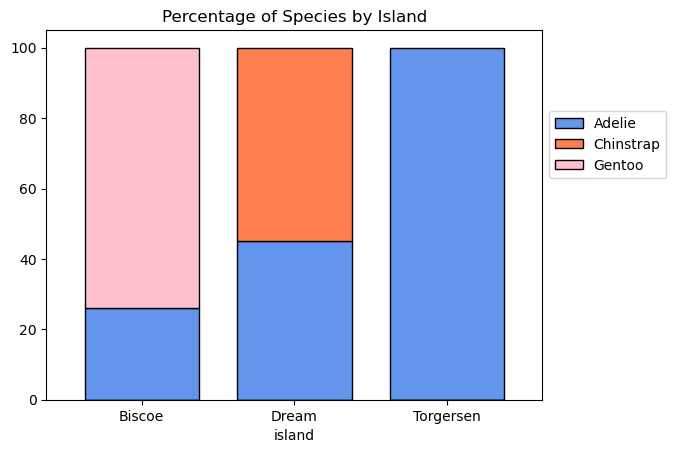

In [9]:
(pd.crosstab(penguins['island'], penguins['species'],  normalize = 'index') * 100).plot(kind = 'bar', 
                                                                                        stacked = True,
                                                                                        color = ['cornflowerblue', 'coral', 'pink'],
                                                                                        edgecolor = 'black',
                                                                                        width = 0.75,
                                                                                       )
plt.title('Percentage of Species by Island')
plt.xticks(rotation = 0)
plt.legend(bbox_to_anchor = (1, 0.8), loc = 'upper left');   # move the legend to the right side of the plot

## Categorical-Numeric Combinations

Let's say we want to look at the average body mass by species. One way to do this is to use `.groupby`.

Quite often when using `.groupby()`, our goal is to calculate an aggregate value by group. To use `.groupby()`, we need to tell pandas: 
* **what** to group by
* **which** column (or columns) we want to aggregate
* **how** to aggregate

In this case, we want to group by `species` and then aggregate the `body_mass_g` column by taking the _mean_.

In [10]:
penguins.groupby('species')['body_mass_g'].mean()

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64

You can even use `.describe` with `groupby` to get even more information by species.

In [11]:
penguins.groupby('species')['body_mass_g'].describe()

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Adelie,151.0,3700.662252,458.566126,2850.0,3350.0,3700.0,4000.0,4775.0
Chinstrap,68.0,3733.088235,384.335081,2700.0,3487.5,3700.0,3950.0,4800.0
Gentoo,123.0,5076.016260,504.116237,3950.0,4700.0,5000.0,5500.0,6300.0


**Question:** Looking at the summary statistics by group, what do you notice?

We can easily compare distributions using a grouped boxplot.

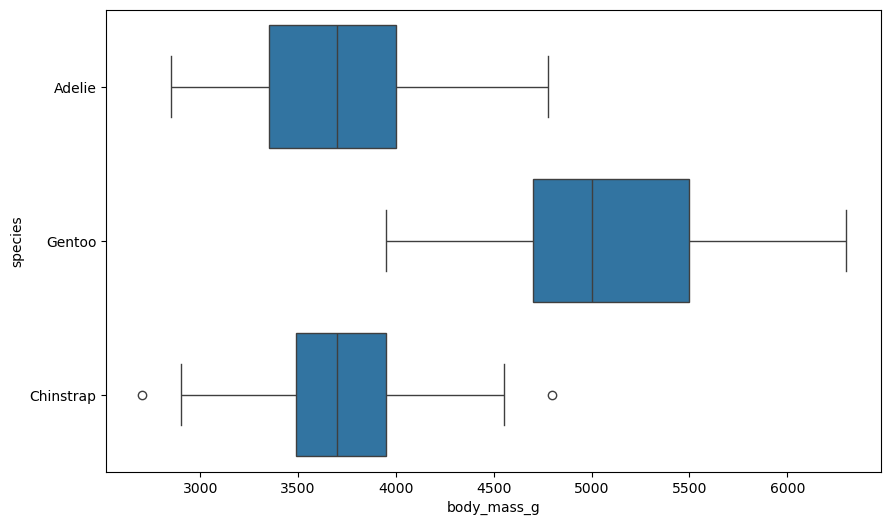

In [12]:
plt.figure(figsize = (10,6))

sns.boxplot(data = penguins,
           x = 'body_mass_g',
           y = 'species');

## Comparing Two Numeric Variables

One way to assess the relationship between two numeric variables is to find the correlation. This can be accomplished using the `.corr()` method, which returns the correlation matrix.

In [13]:
penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


**Question:** Do you notice anything interesting when inspecting the correlation values?

Let's investigate the relationship between bill length and bill depth. We can do this using a scatterplot.

First, let's use the `.plot` method from pandas.

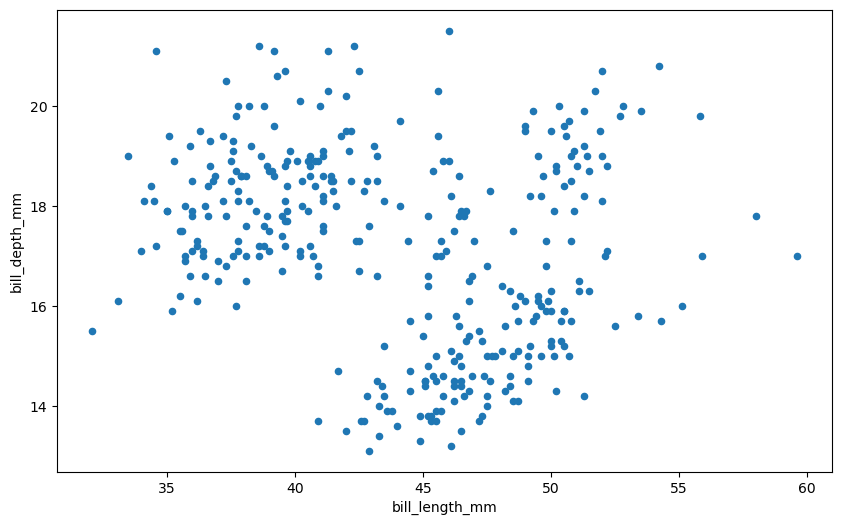

In [14]:
penguins.plot(kind = 'scatter',
             x = 'bill_length_mm',
             y = 'bill_depth_mm',
             figsize = (10,6));

We do need to remember that we have multiple species of penguins. To get a better understanding of the relationship between these variables, we could color the points by species. The easiest way to do this is using the _seaborn_ library.

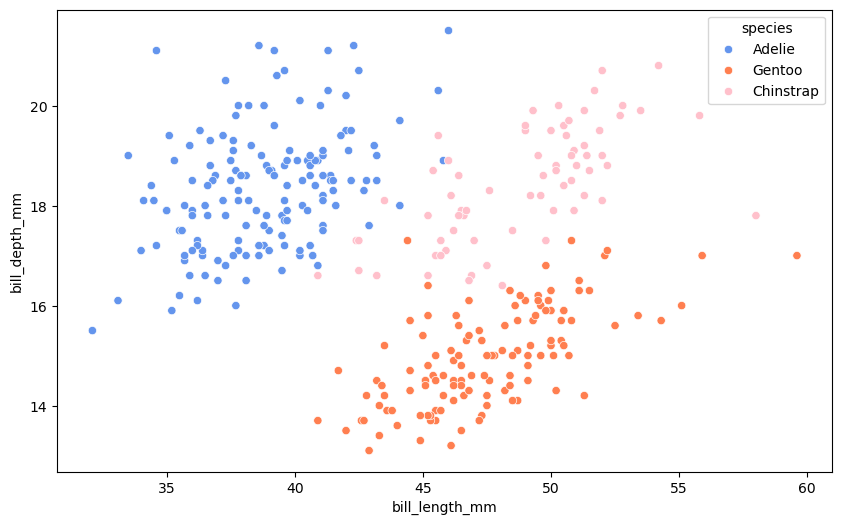

In [15]:
plt.figure(figsize = (10,6))

sns.scatterplot(data = penguins,
               x = 'bill_length_mm',
               y = 'bill_depth_mm',
               hue = 'species',
               palette = ['cornflowerblue', 'coral', 'pink']);

# End of Instruction

### Read in the schools_clean .csv

In [31]:
schools = pd.read_csv('./data/schools_clean.csv')

schools.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   level        167 non-null    object 
 1   name         167 non-null    object 
 2   zipcode      167 non-null    int64  
 3   grade_k      83 non-null     float64
 4   grade_1      83 non-null     float64
 5   grade_2      84 non-null     float64
 6   grade_3      84 non-null     float64
 7   grade_4      83 non-null     float64
 8   grade_5      56 non-null     float64
 9   grade_6      55 non-null     float64
 10  grade_7      56 non-null     float64
 11  grade_8      57 non-null     float64
 12  grade_9      32 non-null     float64
 13  grade_10     34 non-null     float64
 14  grade_11     32 non-null     float64
 15  grade_12     32 non-null     float64
 16  native_amer  94 non-null     float64
 17  asian        141 non-null    float64
 18  black        167 non-null    int64  
 19  hisp    

### Make a crosstab of zipcode and level

In [22]:
pd.crosstab(schools['zipcode'], schools['level'],  normalize = 'index')

level,Adult,Alternative Learning Center,Charter,Elementary School,High School,Middle School,Non-Traditional,Non-Traditional - Hybrid,Special Education
zipcode,,,,,,,,,
37013,0.000000,0.000000,0.190476,0.476190,0.095238,0.190476,0.047619,0.000000,0.000000
37027,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
37072,0.000000,0.000000,0.000000,0.666667,0.000000,0.333333,0.000000,0.000000,0.000000
37076,0.000000,0.000000,0.000000,0.800000,0.000000,0.200000,0.000000,0.000000,0.000000
37080,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.000000,0.000000,0.000000
37115,0.000000,0.000000,0.250000,0.625000,0.000000,0.125000,0.000000,0.000000,0.000000
37138,0.000000,0.000000,0.000000,0.666667,0.000000,0.333333,0.000000,0.000000,0.000000
37189,0.000000,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000
37203,0.000000,0.000000,0.000000,0.333333,0.333333,0.333333,0.000000,0.000000,0.000000


### Now make the same crosstab normalized

In [23]:
pd.crosstab(schools['zipcode'], schools['level'],  normalize = 'all')

level,Adult,Alternative Learning Center,Charter,Elementary School,High School,Middle School,Non-Traditional,Non-Traditional - Hybrid,Special Education
zipcode,,,,,,,,,
37013,0.000000,0.000000,0.023952,0.059880,0.011976,0.023952,0.005988,0.000000,0.000000
37027,0.000000,0.000000,0.000000,0.005988,0.000000,0.000000,0.000000,0.000000,0.000000
37072,0.000000,0.000000,0.000000,0.011976,0.000000,0.005988,0.000000,0.000000,0.000000
37076,0.000000,0.000000,0.000000,0.023952,0.000000,0.005988,0.000000,0.000000,0.000000
37080,0.000000,0.000000,0.000000,0.005988,0.000000,0.005988,0.000000,0.000000,0.000000
37115,0.000000,0.000000,0.011976,0.029940,0.000000,0.005988,0.000000,0.000000,0.000000
37138,0.000000,0.000000,0.000000,0.011976,0.000000,0.005988,0.000000,0.000000,0.000000
37189,0.000000,0.000000,0.000000,0.005988,0.005988,0.000000,0.000000,0.000000,0.000000
37203,0.000000,0.000000,0.000000,0.011976,0.011976,0.011976,0.000000,0.000000,0.000000


### Now make that crosstob into a stacked barchart where each bar totals 100%

<Axes: xlabel='zipcode'>

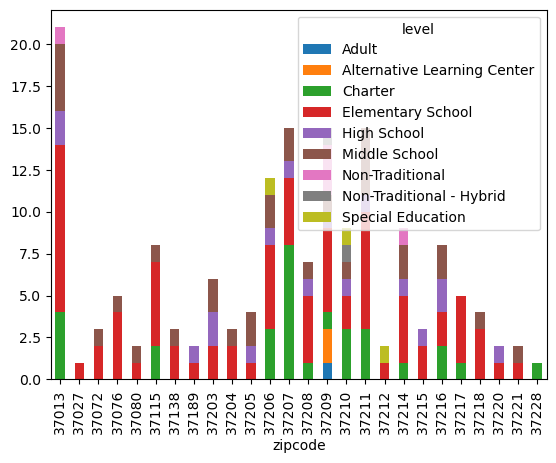

In [29]:
pd.crosstab(schools['zipcode'], schools['level']).plot(kind = 'bar', 
                                                          stacked = True)

### Now group by zipcode and find the number of different levels each zipcode has.  (Look up the nunique() method)

In [32]:
schools.groupby('zipcode')['level'].nunique()

zipcode
37013    5
37027    1
37072    2
37076    2
37080    2
37115    3
37138    2
37189    2
37203    3
37204    2
37205    3
37206    5
37207    4
37208    4
37209    8
37210    6
37211    4
37212    2
37214    5
37215    2
37216    4
37217    2
37218    2
37220    2
37221    2
37228    1
Name: level, dtype: int64

### Now find the average total students by school level.   (This will be a multi-step problem)

In [35]:
grade_cols = ['grade_k', 'grade_1', 'grade_2', 'grade_3', 'grade_4', 'grade_5',
              'grade_6', 'grade_7', 'grade_8', 'grade_9', 'grade_10', 'grade_11', 'grade_12']

schools['total_students'] = schools[grade_cols].sum(axis=1)

In [36]:
schools.groupby('level')['total_students'].mean()

level
Adult                           262.000000
Alternative Learning Center      49.500000
Charter                         451.366667
Elementary School               399.776316
High School                    1135.705882
Middle School                   580.870968
Non-Traditional                 147.200000
Non-Traditional - Hybrid        104.000000
Special Education                95.333333
Name: total_students, dtype: float64